# setup + load labelled test set

In [1]:
import os, sys, numpy as np, pandas as pd, torch
os.chdir("/root/tf-project/venv/Projects/BehaviouralAnalysis")
sys.path.append("src")
from clf import score

d = pd.read_parquet("data/processed/labelled.parquet")
# rebuild the SAME test split used in Phase C (same seed/stratify)
from sklearn.model_selection import train_test_split
Y = d[["y_para","y_bully","y_fin"]].values.astype(float)
tr, te = train_test_split(np.arange(len(d)), test_size=0.2, random_state=0,
                          stratify=d.y_bully)
te_texts = [d.text.iloc[i] for i in te]
Yte = Y[te]
print("test posts:", len(te))

test posts: 499


# 2. Baseline 1: using off-the-shelf toxicity model

In [2]:
from transformers import pipeline
# a widely-used toxicity classifier (no fine-tuning — used as-is)
tox = pipeline("text-classification", model="unitary/toxic-bert",
               top_k=None, device=0, truncation=True, max_length=192)

# map toxicity -> our bullying dimension (the closest match)
tox_scores = []
for t in te_texts:
    r = tox(t[:500])[0]
    tox_prob = max([x["score"] for x in r if x["label"] in
                    ("toxic","severe_toxic","insult","threat","identity_hate")], default=0)
    tox_scores.append(tox_prob)
tox_scores = np.array(tox_scores)

# evaluate toxicity model AS a bullying detector
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support
auc_tox = roc_auc_score(Yte[:,1], tox_scores)
pred = (tox_scores >= 0.5).astype(int)
p,r,f,_ = precision_recall_fscore_support(Yte[:,1], pred, average="binary", zero_division=0)
print(f"toxic-bert AS bullying detector: AUC={auc_tox:.3f} P={p:.2f} R={r:.2f} F1={f:.3f}")
print("(compare to your DAPT bullying: AUC 0.88, F1 0.53)")
# NOTE: toxicity models only cover bullying-like harm — they have NO concept of
# parasocial or financial harm. That's itself a key finding: off-the-shelf tools
# cannot even represent 2 of your 3 harm dimensions.

config.json:   0%|          | 0.00/811 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


toxic-bert AS bullying detector: AUC=0.719 P=0.44 R=0.14 F1=0.215
(compare to your DAPT bullying: AUC 0.88, F1 0.53)


# 3 — BASELINE 2: vanilla XLM-R (no DAPT), fine-tuned on my labels

In [3]:
from transformers import AutoTokenizer, AutoModel
from clf import FocalLoss, Posts, HarmClassifier
from torch.utils.data import DataLoader

# SAME training recipe as your final model, but base xlm-roberta (no DAPT)
tok_v = AutoTokenizer.from_pretrained("xlm-roberta-base")
def loader_v(idx, bs=16, shuffle=False):
    return DataLoader(Posts([d.text.iloc[i] for i in idx], Y[idx], tok_v),
                      batch_size=bs, shuffle=shuffle)

mv = HarmClassifier(AutoModel.from_pretrained("xlm-roberta-base")).cuda()
pos = Y[tr].sum(0); pw = torch.tensor((len(tr)-pos)/np.maximum(pos,1),
                                       dtype=torch.float).cuda()
lf = FocalLoss(gamma=1.0, pos_weight=pw)          # same as final config
opt = torch.optim.AdamW(mv.parameters(), lr=2e-5)
for e in range(4):
    mv.train()
    for ids,mask,y in loader_v(tr, shuffle=True):
        opt.zero_grad(); loss=lf(mv(ids.cuda(),mask.cuda()),y.cuda())
        loss.backward(); opt.step()
    print(f"epoch {e+1} done")

mv.eval(); probs=[]
with torch.no_grad():
    for ids,mask,y in loader_v(te):
        probs.append(torch.sigmoid(mv(ids.cuda(),mask.cuda())).cpu().numpy())
probV = np.vstack(probs)
mV = score(Yte, probV)
print("=== vanilla XLM-R (no DAPT) ==="); [print(" ",k,v) for k,v in mV.items()]
import gc; del mv; gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


epoch 1 done
epoch 2 done
epoch 3 done
epoch 4 done
=== vanilla XLM-R (no DAPT) ===
  parasocial {'precision': 0.127, 'recall': 0.635, 'f1': 0.212, 'auc': 0.643, 'support': 52}
  bullying {'precision': 0.251, 'recall': 0.857, 'f1': 0.389, 'auc': 0.865, 'support': 49}
  financial {'precision': 0.203, 'recall': 0.696, 'f1': 0.314, 'auc': 0.794, 'support': 23}


# 4 — comparison table

In [4]:
# your DAPT numbers from Phase C sweep (final model)
dapt = {"parasocial":{"auc":0.73,"f1":0.31},
        "bullying":{"auc":0.88,"f1":0.53},
        "financial":{"auc":0.87,"f1":0.38}}

rows=[]
for dim in ["parasocial","bullying","financial"]:
    rows.append({"dimension":dim,
                 "toxic-bert_AUC": round(auc_tox,3) if dim=="bullying" else "N/A",
                 "vanillaXLMR_AUC": mV[dim]["auc"],
                 "DAPT_AUC": dapt[dim]["auc"]})
comp = pd.DataFrame(rows)
print(comp)
comp.to_csv("data/processed/baseline_comparison.csv", index=False)

    dimension toxic-bert_AUC  vanillaXLMR_AUC  DAPT_AUC
0  parasocial            N/A            0.643      0.73
1    bullying          0.719            0.865      0.88
2   financial            N/A            0.794      0.87


# A — parasocial proxy: emotion model

### Proxy baseline A — parasocial (emotion model)

No purpose-built parasocial-harm model exists, so the nearest generic proxy is used:
an emotion classifier (`SamLowe/roberta-base-go_emotions`, safetensors format).
Parasocial risk is proxied by summing attachment/longing emotions (love, admiration,
desire, caring, grief, sadness). Deliberately imperfect — the point is to show that
even the closest available generic tool falls short of the domain-adapted model.

In [11]:
from transformers import pipeline
emo = pipeline("text-classification",
               model="SamLowe/roberta-base-go_emotions",   # ships safetensors
               top_k=None, device=0, truncation=True, max_length=192)
print("loaded")

config.json:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

loaded


In [12]:
para_scores = []
for t in te_texts:
    r = {x["label"]: x["score"] for x in emo(t[:500])[0]}
    # parasocial proxy: love/admiration/desire (attachment) + grief/sadness (longing)
    para_scores.append(r.get("love",0) + r.get("admiration",0) + r.get("desire",0)
                       + r.get("caring",0) + r.get("grief",0) + r.get("sadness",0))
para_scores = np.array(para_scores)

from sklearn.metrics import roc_auc_score, precision_recall_fscore_support
auc_emo = roc_auc_score(Yte[:,0], para_scores)
pred = (para_scores >= np.median(para_scores)).astype(int)
p,rc,f,_ = precision_recall_fscore_support(Yte[:,0], pred, average="binary", zero_division=0)
print(f"emotion-model AS parasocial detector: AUC={auc_emo:.3f} P={p:.2f} R={rc:.2f} F1={f:.3f}")

emotion-model AS parasocial detector: AUC=0.550 P=0.12 R=0.56 F1=0.192


# B — financial proxy: zero-shot classification

### Proxy baseline B — financial (zero-shot classification)

No off-the-shelf fandom-financial-harm model exists, so a zero-shot NLI classifier
(`MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli`, safetensors) is used to judge each
post against "financial distress or overspending" vs "normal / no financial content".
Zero-shot lets a general model attempt the task with no training — again a proxy,
to demonstrate the gap versus the purpose-built model.

In [13]:
zs = pipeline("zero-shot-classification",
              model="MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli",  # safetensors
              device=0)

config.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  369MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.28k [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

In [14]:

# force a financial-harm judgement from a general NLI model
labels = ["financial distress or overspending", "normal or no financial content"]
fin_scores = []
for i, t in enumerate(te_texts):
    r = zs(t[:400], labels)
    # score for the 'distress' label
    score_map = dict(zip(r["labels"], r["scores"]))
    fin_scores.append(score_map["financial distress or overspending"])
    if i % 100 == 0: print(f"{i}/{len(te_texts)}")
fin_scores = np.array(fin_scores)

auc = roc_auc_score(Yte[:,2], fin_scores)
pred = (fin_scores >= 0.5).astype(int)
p,rc,f,_ = precision_recall_fscore_support(Yte[:,2], pred, average="binary", zero_division=0)
print(f"zero-shot BART AS financial detector: AUC={auc:.3f} P={p:.2f} R={rc:.2f} F1={f:.3f}")
print("(your DAPT financial: AUC 0.87)")
auc_zs = auc

0/499
100/499
200/499
300/499
400/499
zero-shot BART AS financial detector: AUC=0.590 P=0.06 R=0.43 F1=0.101
(your DAPT financial: AUC 0.87)


### C — complete comparison table (all cells filled)

In [15]:
import pandas as pd
dapt = {"parasocial":0.73, "bullying":0.88, "financial":0.87}
vanilla = {"parasocial":mV["parasocial"]["auc"], "bullying":mV["bullying"]["auc"],
           "financial":mV["financial"]["auc"]}
offshelf = {"parasocial":round(auc_emo,3), "bullying":round(auc_tox,3),
            "financial":round(auc_zs,3)}
offshelf_name = {"parasocial":"emotion-model","bullying":"toxic-bert","financial":"zero-shot BART"}

comp = pd.DataFrame({
    "dimension": list(dapt.keys()),
    "off_the_shelf_model": [offshelf_name[d] for d in dapt],
    "off_the_shelf_AUC": [offshelf[d] for d in dapt],
    "vanilla_XLMR_AUC": [round(vanilla[d],3) for d in dapt],
    "DAPT_AUC": [dapt[d] for d in dapt],
})
print(comp.to_string(index=False))
comp.to_csv("data/processed/baseline_comparison_full.csv", index=False)

 dimension off_the_shelf_model  off_the_shelf_AUC  vanilla_XLMR_AUC  DAPT_AUC
parasocial       emotion-model              0.550             0.643      0.73
  bullying          toxic-bert              0.719             0.865      0.88
 financial      zero-shot BART              0.590             0.794      0.87


## Figure — Baseline comparison (why domain adaptation was needed)

Grouped bar chart of detection AUC across the three harm dimensions for three
approaches: an off-the-shelf generic model (emotion classifier / toxic-bert /
zero-shot NLI), vanilla XLM-R fine-tuned on the annotated data, and the
domain-adapted (DAPT) model. Values are read directly from the comparison results.
Generic tools barely exceed chance on parasocial (0.55) and financial (0.59) harm;
fine-tuning improves detection, and domain-adaptive pre-training improves it further
across all dimensions — most where harm is semantically subtle. Saved to
`baseline_chart.png`.

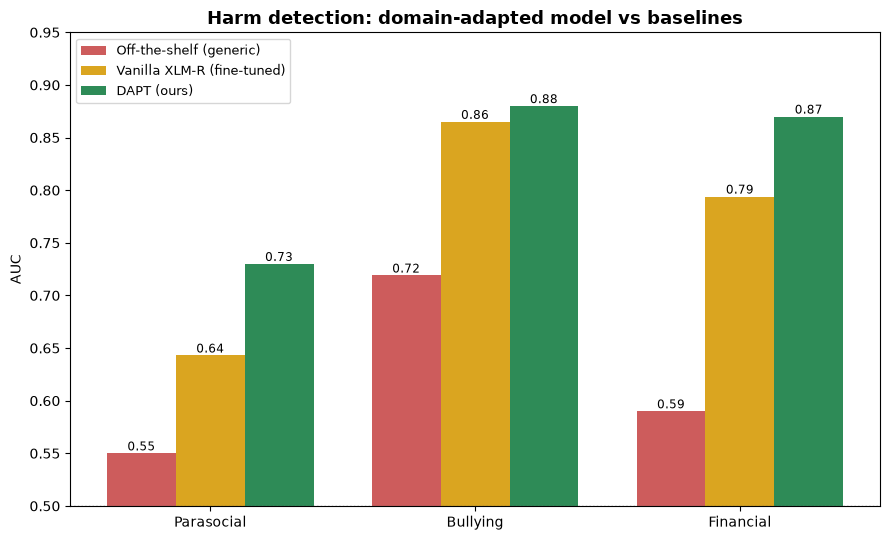

In [16]:
import matplotlib.pyplot as plt
import numpy as np

dims = comp["dimension"].tolist()
series = {
    "Off-the-shelf (generic)":     ("indianred",  comp["off_the_shelf_AUC"].values),
    "Vanilla XLM-R (fine-tuned)":  ("goldenrod",  comp["vanilla_XLMR_AUC"].values),
    "DAPT (ours)":                 ("seagreen",   comp["DAPT_AUC"].values),
}

x = np.arange(len(dims)); w = 0.26
fig, ax = plt.subplots(figsize=(9, 5.5))
for i, (label, (color, vals)) in enumerate(series.items()):
    bars = ax.bar(x + (i-1)*w, vals, w, label=label, color=color)
    for b in bars:
        ax.annotate(f"{b.get_height():.2f}",
                    (b.get_x()+b.get_width()/2, b.get_height()),
                    ha="center", va="bottom", fontsize=8.5)

ax.axhline(0.5, color="grey", ls=":", lw=1)
ax.set_ylabel("AUC"); ax.set_ylim(0.5, 0.95)
ax.set_xticks(x); ax.set_xticklabels([d.capitalize() for d in dims])
ax.set_title("Harm detection: domain-adapted model vs baselines", fontsize=13, weight="bold")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("data/processed/baseline_chart.png", dpi=150)
plt.show()

## Figure — Typology–harm concentration at full corpus scale

Heatmap of Index Scores (harm rate within each behavioural type ÷ population rate ×
100) computed from classifier predictions across the full 2.26M-post corpus. Values
above 100 (warm colours) indicate a type over-represents that harm. The result
reproduces the pattern found in the annotated sample: Conflict-Exposed concentrates
bullying (240), Financially Intensive concentrates financial harm (292), and Devoted
concentrates parasocial risk (128) — while each remains low on the other harms,
confirming that harm modalities are dissociable and type-specific at scale. Saved to
`index_fullcorpus.png`.

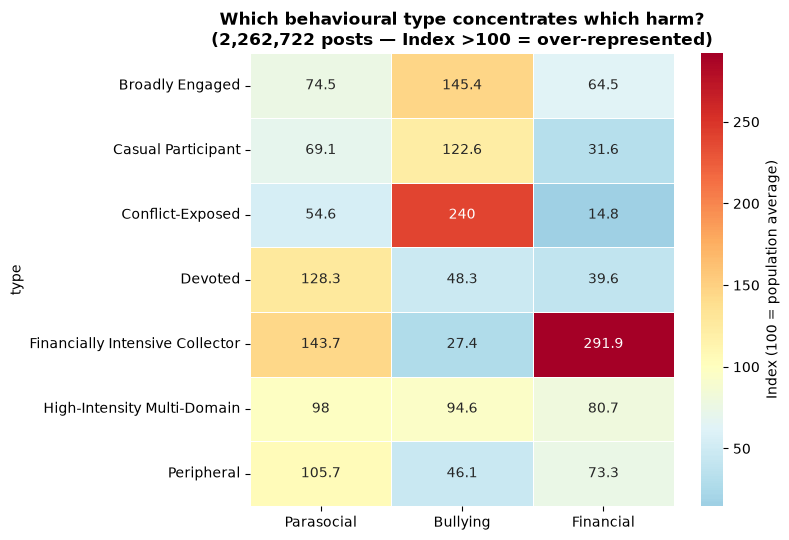

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# rename the prediction columns to readable labels
rename = {"pred_para": "Parasocial", "pred_bully": "Bullying", "pred_fin": "Financial"}
idx_plot = idx_full.rename(columns=rename)

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.heatmap(idx_plot, annot=True, fmt="g", center=100, cmap="RdYlBu_r",
            cbar_kws={"label": "Index (100 = population average)"},
            linewidths=0.5, ax=ax)
n_posts = len(allp)   # from Cell 5 — the full corpus you scored
ax.set_title(f"Which behavioural type concentrates which harm?\n"
             f"({n_posts:,} posts — Index >100 = over-represented)",
             fontsize=12, weight="bold")
plt.tight_layout()
plt.savefig("data/processed/index_fullcorpus.png", dpi=150)
plt.show()

═══════════════════════════════════════════════════════════ PART 2 — FULL 1M CORPUS INDEX SCORES (robustness) ═══════════════════════════════════════════════════════════

# 5 — score ALL feature-eligible posts with the final classifier

In [5]:
from transformers import AutoTokenizer, AutoModel
from clf import HarmClassifier

tok = AutoTokenizer.from_pretrained("models/dapt_final")
model = HarmClassifier(AutoModel.from_pretrained("models/dapt_final"))
model.load_state_dict(torch.load("models/harm_clf_final.pt"))
model.cuda().eval()

# all scored posts (full corpus) with user->cluster mapping
allp = pd.read_parquet("data/processed/posts_scored.parquet")
cl = pd.read_parquet("data/processed/user_clusters.parquet")
allp["type"] = allp.uid.map(cl.set_index("uid").type)
allp = allp.dropna(subset=["type"])
print("full corpus posts with cluster:", len(allp))

@torch.no_grad()
def predict_all(texts, bs=128):
    out=[]
    for i in range(0,len(texts),bs):
        e=tok(texts[i:i+bs],truncation=True,max_length=192,padding=True,return_tensors="pt").to("cuda")
        out.append(torch.sigmoid(model(e.input_ids,e.attention_mask)).cpu().numpy())
        if i % 12800 == 0: print(f"{i}/{len(texts)}")
    return np.vstack(out)

P = predict_all(allp.text.tolist())
allp["pred_para"]=(P[:,0]>=0.5).astype(int)
allp["pred_bully"]=(P[:,1]>=0.5).astype(int)
allp["pred_fin"]=(P[:,2]>=0.5).astype(int)
allp.to_parquet("data/processed/fullcorpus_predictions.parquet")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: models/dapt_final
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_4309/2609232925.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.co

full corpus posts with cluster: 2262722
0/2262722
12800/2262722
25600/2262722
38400/2262722
51200/2262722
64000/2262722
76800/2262722
89600/2262722
102400/2262722
115200/2262722
128000/2262722
140800/2262722
153600/2262722
166400/2262722
179200/2262722
192000/2262722
204800/2262722
217600/2262722
230400/2262722
243200/2262722
256000/2262722
268800/2262722
281600/2262722
294400/2262722
307200/2262722
320000/2262722
332800/2262722
345600/2262722
358400/2262722
371200/2262722
384000/2262722
396800/2262722
409600/2262722
422400/2262722
435200/2262722
448000/2262722
460800/2262722
473600/2262722
486400/2262722
499200/2262722
512000/2262722
524800/2262722
537600/2262722
550400/2262722
563200/2262722
576000/2262722
588800/2262722
601600/2262722
614400/2262722
627200/2262722
640000/2262722
652800/2262722
665600/2262722
678400/2262722
691200/2262722
704000/2262722
716800/2262722
729600/2262722
742400/2262722
755200/2262722
768000/2262722
780800/2262722
793600/2262722
806400/2262722
819200/22627

# 6 — full-corpus Index Scores + compare to the 2,495 sample

In [6]:
def index_scores(df, cols):
    base={c:df[c].mean() for c in cols}
    rows=[]
    for t,g in df.groupby("type"):
        row={"type":t}
        for c in cols: row[c]=round(g[c].mean()/base[c]*100,1) if base[c]>0 else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index("type")

idx_full = index_scores(allp, ["pred_para","pred_bully","pred_fin"])
print("=== FULL-CORPUS INDEX SCORES ===")
print(idx_full)
idx_full.to_csv("data/processed/index_scores_fullcorpus.csv")
# compare pattern to the 2495 sample (load index_scores.csv) -> if same, robust

=== FULL-CORPUS INDEX SCORES ===
                                 pred_para  pred_bully  pred_fin
type                                                            
Broadly Engaged                       74.5       145.4      64.5
Casual Participant                    69.1       122.6      31.6
Conflict-Exposed                      54.6       240.0      14.8
Devoted                              128.3        48.3      39.6
Financially Intensive Collector      143.7        27.4     291.9
High-Intensity Multi-Domain           98.0        94.6      80.7
Peripheral                           105.7        46.1      73.3
